In [1]:
import rioxarray
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import geemap
import ee
import geopandas as gpd

ee.Authenticate()
ee.Initialize()

xr.set_options(keep_attrs=True, display_expand_data=False)

update.go:85: cannot change mount namespace according to change mount (/var/lib/snapd/hostfs/usr/local/share/doc /usr/local/share/doc none bind,ro 0 0): cannot write to "/var/lib/snapd/hostfs/usr/local/share/doc" because it would affect the host in "/var/lib/snapd"
update.go:85: cannot change mount namespace according to change mount (/var/lib/snapd/hostfs/usr/share/gimp/2.0/help /usr/share/gimp/2.0/help none bind,ro 0 0): cannot write to "/var/lib/snapd/hostfs/usr/share/gimp/2.0/help" because it would affect the host in "/var/lib/snapd"
update.go:85: cannot change mount namespace according to change mount (/var/lib/snapd/hostfs/usr/share/gtk-doc /usr/share/gtk-doc none bind,ro 0 0): cannot write to "/var/lib/snapd/hostfs/usr/share/gtk-doc" because it would affect the host in "/var/lib/snapd"
update.go:85: cannot change mount namespace according to change mount (/var/lib/snapd/hostfs/usr/share/libreoffice/help /usr/share/libreoffice/help none bind,ro 0 0): cannot write to "/var/lib/sna


Successfully saved authorization token.


In [ ]:
# raster_data = rioxarray.open_rasterio('C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/Test/GEMLST_MODIS_20000315.tif')
era5 = xr.open_dataset('/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/Test_Gapfilling/t2m_elvcorr_2000_d075.nc')

# Rename coordinates to standard names for rioxarray
# era5 = era5.rename({'X': 'longitude', 'Y': 'latitude'})

# Select temp var
# era5_temp = era5['t2m']

In [ ]:
print(era5.data_vars, '\n')
for attributes, values in era5.attrs.items():
    print(attributes, values, '\n')

print(f'Y= {len(era5['Y'].values)}, \nX= {len(era5['X'].values[0])}')

Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    t2m        (time, zlev, Y, X) float32 73MB ... 

creation_date 2025-03-27T20:47:23Z 

history 2025-03-27T20:47:23Z ;convert gtool file to netCDF file 

institution Institute of Industrial Science, The University of Tokyo 

contact Yukihiko Onuma(yonuma613@gmail.com) 

Y= 5654, 
X= 3219


libva info: VA-API version 1.20.0
libva info: Trying to open /snap/firefox/7836/gnome-platform/usr/lib/x86_64-linux-gnu/dri/iHD_drv_video.so
libva info: Found init function __vaDriverInit_1_20
libva info: va_openDriver() returns 0
[Child 13995, MediaDecoderStateMachine #1] WARNING: Decoder=7c4f26b0be00 state=DECODING_METADATA Decode metadata failed, shutting down decoder: file /build/firefox/parts/firefox/build/dom/media/MediaDecoderStateMachine.cpp:342
[Child 13995, MediaDecoderStateMachine #1] WARNING: Decoder=7c4f26b0be00 Decode error: NS_ERROR_DOM_MEDIA_METADATA_ERR (0x806e0006) - static MP4Metadata::ResultAndByteBuffer mozilla::MP4Metadata::Metadata(ByteStream *): Cannot parse metadata: file /build/firefox/parts/firefox/build/dom/media/MediaDecoderStateMachineBase.cpp:168


In [4]:
from pyproj import CRS, Transformer
import pandas as pd

# Convert era5_temp lat/lon to EPSG:3413 (x, y in meters)
crs_wgs84 = CRS.from_epsg(4326)  # WGS84
crs_3413 = CRS.from_epsg(3413)   # EPSG:3413
transformer = Transformer.from_crs(crs_wgs84, crs_3413, always_xy=True) # Using always_xy=True ensures (lon, lat) input and (x, y) output

x_proj, y_proj = transformer.transform(
    era5_temp['longitude'].values, 
    era5_temp['latitude'].values
    )

# Assign with explicit dimensions (matching longitude/latitude dimensions)
era5_temp = era5_temp.assign_coords({
    'x_proj': (('latitude', 'longitude'), x_proj),
    'y_proj': (('latitude', 'longitude'), y_proj)
})

# Set the CRS to EPSG:3413
era5_temp = era5_temp.rio.write_crs("EPSG:3413")

# Prepare the spatial dimensions for rioxarray
era5_temp = era5_temp.rio.set_spatial_dims(x_dim='x_proj', y_dim='y_proj')

print(era5_temp.rio.bounds())
print(era5_temp.rio.crs)
print(era5_temp)

MissingSpatialDimensionError: x dimension (x_proj) not found. Data variable: t2m

In [7]:
import numpy as np

# Check if the 2D coordinates are actually on a regular grid
# (i.e., each row has the same x values, each column has the same y values)

lon_2d = era5_temp['longitude'].values
lat_2d = era5_temp['latitude'].values

# Check if longitude is constant along rows
lon_varies_by_row = np.any(np.diff(lon_2d, axis=0) != 0)
# Check if latitude is constant along columns  
lat_varies_by_col = np.any(np.diff(lat_2d, axis=1) != 0)

print(f"Longitude varies across rows: {lon_varies_by_row}")
print(f"Latitude varies across columns: {lat_varies_by_col}")

# If both are False, you can extract 1D arrays!
if not lon_varies_by_row and not lat_varies_by_col:
    x_1d = lon_2d[0, :]  # First row
    y_1d = lat_2d[:, 0]  # First column
    print("✓ Can extract 1D coordinates!")
    print(f"x shape: {x_1d.shape}, y shape: {y_1d.shape}")

Longitude varies across rows: True
Latitude varies across columns: True


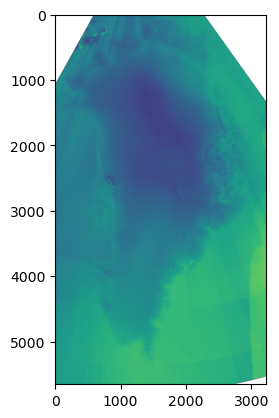

<Axes: >

In [ ]:
from rasterio.plot import show
# show(era5_temp)  # Show the first band of the raster data
show(np.squeeze(era5_temp.values[0,:,:]))
 

### Older parts of the script - drafts

In [ ]:
########### OLDER SCRIPTS FROM HERE ON ########################

# Rename coordinates to standard names for rioxarray
era5 = era5.rename({'X': 'longitude', 'Y': 'latitude'})

# Set CRS (it's EPSG:4326 based on the attributes)
era5['t2m'] = era5['t2m'].rio.write_crs("EPSG:4326")

# Your raster bounds in EPSG:3413
raster_bounds_3413 = (-664000.0, -3486000.0, 946000.0, -658000.0)

# Convert raster bounds to EPSG:4326 to clip ERA5
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:3413", "EPSG:4326", always_xy=True)

# Transform corners
min_lon, min_lat = transformer.transform(raster_bounds_3413[0], raster_bounds_3413[1])
max_lon, max_lat = transformer.transform(raster_bounds_3413[2], raster_bounds_3413[3])

print(f"Greenland bounds in lat/lon: {min_lon}, {min_lat}, {max_lon}, {max_lat}")

# Clip ERA5 to these bounds (using where since it's curvilinear)
lon_mask = (era5.longitude >= min_lon) & (era5.longitude <= max_lon)
lat_mask = (era5.latitude >= min_lat) & (era5.latitude <= max_lat)
combined_mask = lon_mask & lat_mask

era5_clipped = era5.where(combined_mask, drop=True)

# Now reproject to EPSG:3413 to match your rasters
era5_reproj = era5_clipped['t2m'].rio.reproject("EPSG:3413")

print(era5_reproj)

ValueError: cannot rename 'X' because it is not a variable or dimension in this dataset

c:\Users\simon\miniconda3\envs\gem\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


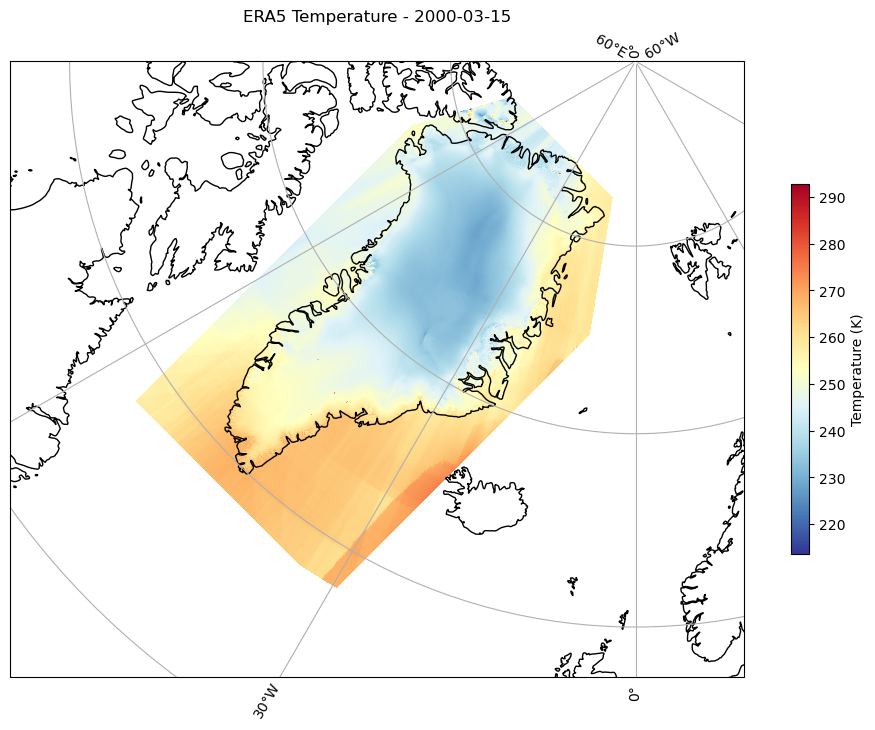

Temperature range: 213.59 - 292.70 K
Mean: 251.31 K
Data shape: (5654, 3219)


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Get temperature for first timestep
temp = era5.t2m.isel(time=0, zlev=0)
lons = era5.X.values
lats = era5.Y.values

# Create figure with map projection
fig, ax = plt.subplots(figsize=(12, 8), 
                       subplot_kw={'projection': ccrs.NorthPolarStereo()})

# Plot the temperature data
im = ax.pcolormesh(lons, lats, temp, 
                   transform=ccrs.PlateCarree(),
                   cmap='RdYlBu_r', 
                   shading='auto')

# Add features
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_extent([-90, 10, 57, 84], crs=ccrs.PlateCarree())  # Focus on Greenland

# Colorbar
plt.colorbar(im, ax=ax, label='Temperature (K)', shrink=0.6)
plt.title('ERA5 Temperature - 2000-03-15')
plt.show()

# Print some stats
print(f"Temperature range: {temp.min().values:.2f} - {temp.max().values:.2f} K")
print(f"Mean: {temp.mean().values:.2f} K")
print(f"Data shape: {temp.shape}")

In [ ]:
import rasterio
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rioxarray as rxr
import ee
import geemap
ee.Initialize()

In [ ]:
greenlandmask = ee.Image('OSU/GIMP/2000_ICE_OCEAN_MASK').select('ocean_mask').eq(0)

src = rasterio.open('C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/Test/GEMLST_MODIS_20000315.tif')
raster_data= src.read(1)
raster_transform = src.transform

era5 = xr.open_dataset('C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/Test/t2m_elvcorr_2000_d075.nc')
era5_data = (era5['t2m']
    .rename({'Y': 'y', 'X': 'x'})
    .rio.set_spatial_dims(x_dim='x', y_dim='y')
    .rio.write_crs('EPSG:3413', inplace=True)
)

In [ ]:
# Mask ERA5 data with Greenland mask
era5_masked = np.where(greenlandmask == 1, era5_data, np.nan)
raster_masked = np.where(greenlandmask == 1, raster_data, np.nan)
# Should I also mask the raster here again to ensure uniformity?

In [ ]:
### ALTERNATIVE ATTEMPT TO FORCE REPROJECTION USING rasterio.warp REPROJECT

# from rasterio.warp import reproject, Resampling

# # Create an empty array for the reprojected data
# dst_array = np.empty_like(raster_masked)

# # Reproject using rasterio.warp
# reproject(
#     source=era5_masked[0, 0, :, :],  # Extract 2D array from 4D array
#     destination=dst_array,
#     src_transform=era5_data.rio.transform(),
#     src_crs=era5_data.rio.crs,
#     dst_transform=raster_transform,
#     dst_crs='EPSG:3413',
#     resampling=Resampling.nearest
# )


TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
### check shapes and transforms
# Print extent of raster and ERA5 data
print(f"Raster shape: {raster_masked.shape}")
print(f"Raster transform: {raster_transform}")

# Print transformation of era5
print(f"ERA5 shape: {era5_masked.shape}")

print(2*int(raster_masked.shape[0]), 2*int(raster_masked.shape[1]))

Raster shape: (2828, 1610)
Raster transform: | 1000.00, 0.00,-664000.00|
| 0.00,-1000.00,-658000.00|
| 0.00, 0.00, 1.00|
ERA5 shape: (1, 1, 5654, 3219)
ERA5 CRS: EPSG:3413
5656 3220


In [ ]:
# Create a reference DataArray for reprojection
reference_raster = xr.DataArray(
    raster_masked,
    coords={
        'y': np.arange(raster_masked.shape[0]),
        'x': np.arange(raster_masked.shape[1]),
    },
    dims=('y', 'x'),
    attrs={'transform': raster_transform}
).rio.write_crs('EPSG:3413')

# Set spatial dimensions for the reference raster
reference_raster = reference_raster.rio.set_spatial_dims(x_dim='x', y_dim='y')

# Reproject ERA5 to match the reference raster
era5_reprojected = era5_data.rio.reproject_match(reference_raster)


TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
# Reproject ERA5 to match the raster
# Assign the CRS to era5_data
era5_data_with_crs = era5_data.rio.write_crs('EPSG:3413', inplace=False).rio.set_spatial_dims(x_dim='X', y_dim='Y')

# Create a reference DataArray from raster_data for reproject_match
# This DataArray will carry the spatial information (CRS, transform, shape) of the raster.
raster_match_reference = xr.DataArray(
    raster_data,
    coords={
        "y": np.arange(raster_data.shape[0]),
        "x": np.arange(raster_data.shape[1]),
    },
    dims=("y", "x"),
    name="raster_match_reference",
    attrs={'transform': raster_transform} # Set the transform directly in attributes
).rio.write_crs(raster.crs)

# Set spatial dimensions for rioxarray
raster_match_reference = raster_match_reference.rio.set_spatial_dims(x_dim='x', y_dim='y')

# Reproject era5_data to match the spatial properties of the raster
era5_reprojected = era5_data_with_crs.rio.reproject_match(raster_match_reference)

# Convert the reprojected ERA5 temperature to Celsius
era5_celsius = era5_reprojected - 273.15

MissingSpatialDimensionError: x dimension (X) not found. Data variable: t2m